# 🗞️ NYT Articles Naive Bayes Classifier

**Objetivo**: Implementar un clasificador Bernoulli Naive Bayes desde cero para predecir la sección de artículos del New York Times, siguiendo un pipeline de Machine Learning robusto y eficiente.

**Dataset**: Artículos únicos distribuidos en 5 categorías balanceadas.

**Pipeline**:
1.  **Setup & Data Loading**: Carga de datos y librerías.
2.  **Text Preprocessing**: Limpieza de texto eficiente usando `spaCy`.
3.  **Feature Engineering**: Creación de una matriz `Document-Term` dispersa.
4.  **Model Implementation**: Creación de una clase `BernoulliNB` modular desde cero.
5.  **Training & Evaluation**: Entrenamiento, predicción y evaluación completa.
6.  **Deep Analysis**: Análisis de palabras informativas y errores del modelo.
7.  **Hyperparameter Tuning**: Experimentación sistemática con hiperparámetros.
8.  **Executive Summary**: Conclusiones y resumen final autogenerado.

## 📊 1. SETUP, LIBRERÍAS Y CARGA DE DATOS
Aquí se importan todas las librerías necesarias y se centraliza la configuración del proyecto para facilitar la reproducibilidad y los ajustes.

In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import time
from tqdm.notebook import tqdm # Usar tqdm.notebook para mejores barras de progreso en notebooks
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import spacy
from scipy.sparse import csr_matrix
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURACIÓN CENTRALIZADA ---
# Importante: actualiza esta ruta a la ubicación de tu archivo.
DATA_PATH = Path(r"C:\Users\PC\Documents\doing-data-science\chapter-04\NYT_ControlledYield_Dataset_20250730-185835\collected_articles.csv")
TARGET_COLUMN = 'category'
TEXT_COLUMN = 'text'
VOCAB_SIZE = 5000  # Valor inicial, se afina de acuerdo a los experimentos
RANDOM_STATE = 42 
TEST_SIZE = 0.5

# --- ESTILO DE PLOTS ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print("Librerías y configuración cargadas.")

Librerías y configuración cargadas.


 Dataset cargado con éxito: 1196 artículos.

📊 DISTRIBUCIÓN POR CATEGORÍA:


category
News        296
Business    250
Culture     250
Sports      200
Science     200
Name: count, dtype: int64

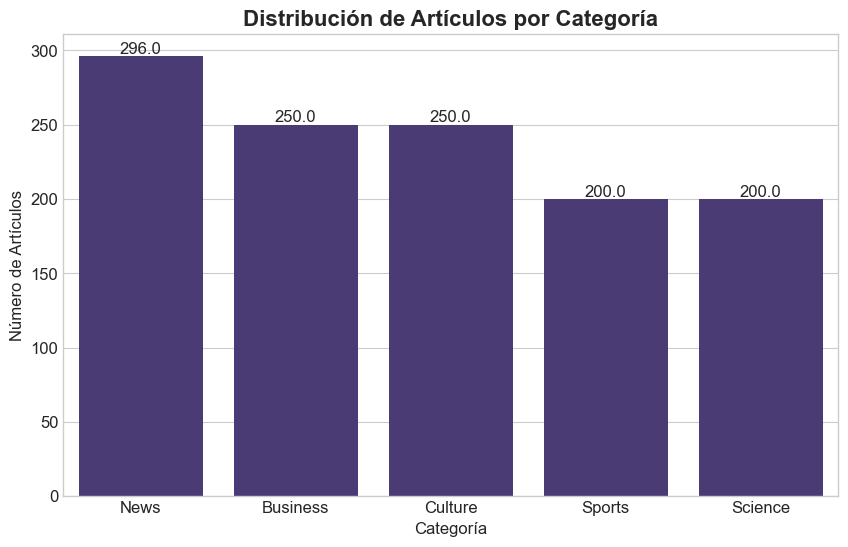

In [ ]:

# --- Carga y validación inicial del dataset ---
try:
    df = pd.read_csv(DATA_PATH)
    df[TEXT_COLUMN] = df['title'].fillna('') + ' ' + df['body'].fillna('')
    df.dropna(subset=[TEXT_COLUMN, TARGET_COLUMN], inplace=True)
    print(f" Dataset cargado con éxito: {len(df)} artículos.")
except FileNotFoundError:
    print(f" ERROR: No se encontró el archivo en la ruta: {DATA_PATH}")
    print("Por favor, actualiza la variable DATA_PATH con la ruta correcta.")
    df = None

# --- Exploración básica de la distribución de clases ---
if df is not None:
    print("\n📊 DISTRIBUCIÓN POR CATEGORÍA:")
    category_counts = df[TARGET_COLUMN].value_counts()
    display(category_counts)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.countplot(x=TARGET_COLUMN, data=df, order=category_counts.index, ax=ax)
    ax.set_title('Distribución de Artículos por Categoría', fontsize=16, fontweight='bold')
    ax.set_xlabel('Categoría')
    ax.set_ylabel('Número de Artículos')
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.show()

## 🧼 2. PREPROCESAMIENTO DE TEXTO
**Objetivo**: Convertir el texto crudo en una lista de *tokens* limpios para cada documento.
**Estrategia optimizada**:
1.  **Usar `spaCy`**: Para tokenización, lematización y eliminación de *stop words* de forma eficiente.
2.  **Lematización**: `run`, `running`, `ran` -> `run`. Es lingüísticamente más preciso que el *stemming*.
3.  **Procesamiento en Lotes (`nlp.pipe`)**: Para máxima velocidad.

In [16]:

# --- Cargar modelo de spaCy (deshabilitando componentes no necesarios para acelerar) ---
try:
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    print(" Modelo de spaCy 'en_core_web_sm' cargado.")
except OSError:
    print(" Modelo 'en_core_web_sm' no encontrado. Ejecuta: python -m spacy download en_core_web_sm")
    nlp = None

def preprocess_text(texts, nlp_model):
    """Limpia y tokeniza una serie de textos usando spaCy y procesamiento en lotes."""
    preprocessed_texts = []
    # Usar nlp.pipe para un procesamiento mucho más rápido
    for doc in tqdm(nlp_model.pipe(texts, batch_size=50), total=len(texts), desc="Preprocesando texto"):
        tokens = [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
        preprocessed_texts.append(tokens)
    return preprocessed_texts

# --- Aplicar la función de preprocesamiento ---
if df is not None and nlp is not None:
    df['tokens'] = preprocess_text(df[TEXT_COLUMN].tolist(), nlp)
    print("\n Preprocesamiento completado.")
    print("\n MUESTRA DE TOKENS PROCESADOS:")
    display(df[['text', 'tokens']].head(2))

 Modelo de spaCy 'en_core_web_sm' cargado.


Preprocesando texto:   0%|          | 0/1196 [00:00<?, ?it/s]


 Preprocesamiento completado.

 MUESTRA DE TOKENS PROCESADOS:


,text,tokens
0,How Texas Republicans Want to Flip These Democ...,"[texas, republicans, want, flip, democratic, u..."
1,‘Loyalty Enforcer’ Laura Loomer Targets Additi...,"[loyalty, enforcer, laura, loomer, target, add..."


## 🛠️ 3. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
**Objetivo**: Convertir las listas de tokens en una matriz numérica que el modelo pueda entender.
**Estrategia**:
1.  **Dividir los datos**: Primero separamos en entrenamiento y prueba para evitar *data leakage*. El vocabulario se crea **solo** con los datos de entrenamiento.
2.  **Crear un vocabulario**: Seleccionar las `VOCAB_SIZE` palabras más frecuentes.
3.  **Crear Matriz Documento-Término Binaria**: Para cada documento, un vector indica la presencia (`1`) o ausencia (`0`) de cada palabra del vocabulario.
4.  **Usar `scipy.sparse.csr_matrix`**: Para manejar la matriz de forma ultra eficiente en memoria.

In [ ]:

# --- Dividir los datos en entrenamiento y prueba ---
if df is not None:
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        df[['tokens', TEXT_COLUMN]], 
        df[TARGET_COLUMN], 
        test_size=TEST_SIZE, 
        random_state=RANDOM_STATE,
        stratify=df[TARGET_COLUMN] # Estratificar para mantener proporciones de clases
    )
    print(f"División de datos: {len(X_train_df)} train / {len(X_test_df)} test")

# --- Función para crear la matriz dispersa ---
def create_sparse_matrix(tokenized_texts, word_to_idx_map):
    """Crea una matriz binaria dispersa (CSR format) a partir de textos tokenizados."""
    rows, cols, data = [], [], []
    for i, tokens in enumerate(tokenized_texts):
        unique_tokens_in_doc = set(tokens)
        for token in unique_tokens_in_doc:
            if token in word_to_idx_map:
                rows.append(i)
                cols.append(word_to_idx_map[token])
                data.append(1)
    return csr_matrix((data, (rows, cols)), shape=(len(tokenized_texts), len(word_to_idx_map)))

if 'X_train_df' in locals():
    # 1. Crear vocabulario desde el CONJUNTO DE ENTRENAMIENTO
    word_counts = Counter(word for tokens_list in X_train_df['tokens'] for word in tokens_list)
    vocabulary = {word for word, count in word_counts.most_common(VOCAB_SIZE)}
    word_to_idx = {word: i for i, word in enumerate(vocabulary)}
    print(f" Vocabulario creado con las {len(vocabulary)} palabras más frecuentes.")

    # 2. Crear matrices para entrenamiento y prueba
    X_train_sparse = create_sparse_matrix(X_train_df['tokens'], word_to_idx)
    X_test_sparse = create_sparse_matrix(X_test_df['tokens'], word_to_idx)
    print(f" Matrices dispersas creadas. Forma de entrenamiento: {X_train_sparse.shape}")
    
    density = (X_train_sparse.nnz / (X_train_sparse.shape[0] * X_train_sparse.shape[1])) * 100
    print(f"Densidad de la matriz: {density:.2f}% (muy dispersa, ¡eficiencia máxima!)")

División de datos: 598 train / 598 test
 Vocabulario creado con las 3871 palabras más frecuentes.
 Matrices dispersas creadas. Forma de entrenamiento: (598, 3871)
Densidad de la matriz: 0.42% (muy dispersa, ¡eficiencia máxima!)


## 🧠 4. IMPLEMENTACIÓN DE NAIVE BAYES DESDE CERO
**Objetivo**: Crear una clase `BernoulliNB` que encapsule toda la lógica.
**Buenas prácticas**:
- **API tipo `scikit-learn`**: Con métodos `.fit()` y `.predict()`.
- **Suavizado de Laplace (`alpha`)**: Para evitar probabilidades de cero.
- **Log-probabilidades**: Para evitar *underflow* numérico y por eficiencia (sumas en vez de multiplicaciones).

In [ ]:

class BernoulliNB:
    """Clasificador Bernoulli Naive Bayes implementado desde cero."""
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        n_docs, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        self.log_class_priors_ = np.zeros(n_classes)
        self.log_feature_probs_ = np.zeros((n_classes, n_features))

        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            n_docs_in_class = X_c.shape[0]
            
            # Calcular log-prior de la clase P(c)
            self.log_class_priors_[i] = np.log(n_docs_in_class / n_docs)
            
            # Calcular log-probabilidades condicionales P(j|c)
            word_counts_in_class = X_c.sum(axis=0) + self.alpha
            total_counts = n_docs_in_class + 2 * self.alpha
            self.log_feature_probs_[i, :] = np.log(word_counts_in_class / total_counts)
            
        return self

    def predict_log_proba(self, X):
        # Para evitar underflow, usamos un truco matemático 
        log_not_feature_probs = np.log(1 - np.exp(self.log_feature_probs_))
        log_prob_diff = self.log_feature_probs_ - log_not_feature_probs
        base_log_probs = np.sum(log_not_feature_probs, axis=1)
        doc_log_probs = X @ log_prob_diff.T
        return doc_log_probs + self.log_class_priors_ + base_log_probs

    def predict(self, X):
        log_probas = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_probas, axis=1)]

print(" Clase BernoulliNB implementada.")

 Clase BernoulliNB implementada.


## 🚀 5. ENTRENAMIENTO Y EVALUACIÓN
**Objetivo**: Entrenar, predecir y evaluar el rendimiento del modelo base.
**Métricas**: `Accuracy`, Matriz de Confusión y Reporte de Clasificación (precision, recall, f1-score).

Entrenando el modelo base...
 Entrenamiento (0.06s) y Predicción (0.0020s) completados.

 EVALUACIÓN (Accuracy: 53.34%)


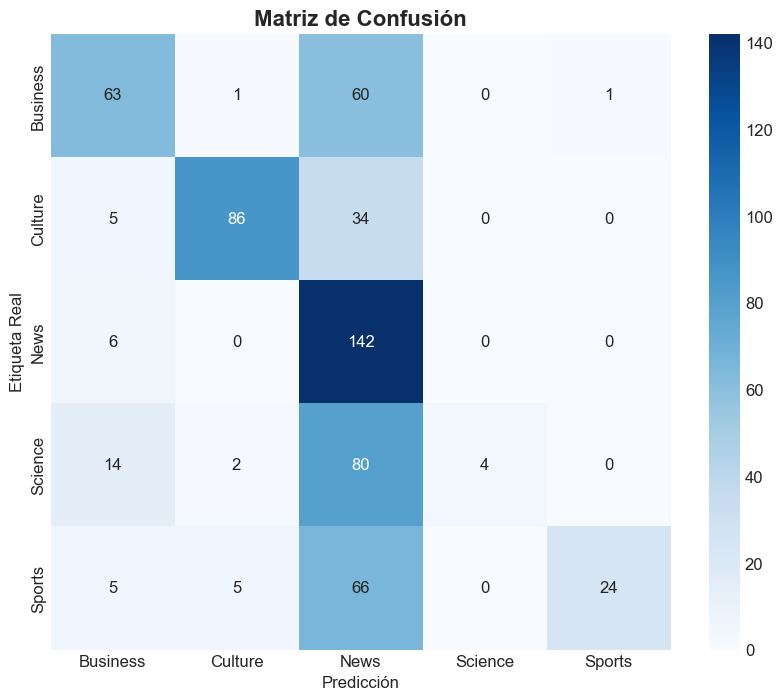


 REPORTE DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

    Business       0.68      0.50      0.58       125
     Culture       0.91      0.69      0.79       125
        News       0.37      0.96      0.54       148
     Science       1.00      0.04      0.08       100
      Sports       0.96      0.24      0.38       100

    accuracy                           0.53       598
   macro avg       0.78      0.49      0.47       598
weighted avg       0.75      0.53      0.49       598



In [19]:

# --- Entrenamiento ---
model = BernoulliNB(alpha=1.0) # alpha=1.0 es el suavizado de Laplace estándar
print("Entrenando el modelo base...")
start_time = time.time()
model.fit(X_train_sparse, y_train.values)
train_time = time.time() - start_time

# --- Predicción ---
start_time = time.time()
y_pred = model.predict(X_test_sparse)
predict_time = time.time() - start_time
print(f" Entrenamiento ({train_time:.2f}s) y Predicción ({predict_time:.4f}s) completados.")

# --- Evaluación ---
final_accuracy = accuracy_score(y_test, y_pred)
print("\n" + "="*50 + f"\n EVALUACIÓN (Accuracy: {final_accuracy:.2%})\n" + "="*50)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Matriz de Confusión', fontsize=16, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

# Reporte de Clasificación
print("\n REPORTE DE CLASIFICACIÓN DETALLADO:")
print(classification_report(y_test, y_pred, target_names=model.classes_))

## 🔬 6. ANÁLISIS PROFUNDO DEL MODELO
**Objetivo**: Entender *qué* aprendió el modelo y *dónde* falla.
1.  **Palabras más informativas**: ¿Qué palabras son las más predictivas para cada categoría?
2.  **Análisis de errores**: ¿Qué artículos confunden más al modelo?

In [20]:

# --- 1. Palabras más informativas por categoría ---
print("\n" + "="*50 + "\n PALABRAS MÁS INFORMATIVAS POR CATEGORÍA\n" + "="*50)
idx_to_word = {i: word for word, i in word_to_idx.items()}
for i, c in enumerate(model.classes_):
    top_10_indices = np.argsort(model.log_feature_probs_[i, :])[-10:]
    top_10_words = [idx_to_word[idx] for idx in reversed(top_10_indices)]
    print(f"\n {c.upper()}: {', '.join(top_10_words)}")

# --- 2. Análisis de los errores más grandes ---
print("\n" + "="*50 + "\n ANÁLISIS DE ERRORES\n" + "="*50)
log_probas = model.predict_log_proba(X_test_sparse)
error_indices = np.where(y_pred != y_test)[0]
error_details = []
for idx in error_indices:
    real_label = y_test.iloc[idx]
    pred_label = y_pred[idx]
    real_class_idx = np.where(model.classes_ == real_label)[0][0]
    pred_class_idx = np.where(model.classes_ == pred_label)[0][0]
    
    confidence_in_error = log_probas[idx, pred_class_idx] - log_probas[idx, real_class_idx]
    error_details.append({
        'real_label': real_label, 'predicted_label': pred_label, 
        'confidence_in_error': confidence_in_error, 'text': X_test_df[TEXT_COLUMN].iloc[idx]
    })

top_errors = sorted(error_details, key=lambda x: x['confidence_in_error'], reverse=True)
print(f"Se encontraron {len(top_errors)} errores. Mostrando los 5 más 'confundentes':\n")
for i, error in enumerate(top_errors[:5]):
    print(f"--- ERROR #{i+1} ---")
    print(f"    • Real: {error['real_label']} | Predicción: {error['predicted_label']}")
    print(f"    • Confianza en el error: {error['confidence_in_error']:.2f}")
    print(f"    • Texto: {error['text'][:250]}...\n")


 PALABRAS MÁS INFORMATIVAS POR CATEGORÍA

 BUSINESS: trump, economy, new, president, say, company, technology, start, tariff, market

 CULTURE: movies, music, film, new, stream, know, include, week, think, critic

 NEWS: trump, president, election, say, result, government, new, map, administration, international

 SCIENCE: climate, change, new, trump, say, year, die, health, administration, study

 SPORTS: week, die, star, game, player, league, playoffs, playoff, team, new

 ANÁLISIS DE ERRORES
Se encontraron 279 errores. Mostrando los 5 más 'confundentes':

--- ERROR #1 ---
    • Real: Sports | Predicción: News
    • Confianza en el error: 24.31
    • Texto: Word of the Day: castigate This word has appeared in 18 articles on NYTimes.com in the past year. Can you use it in a sentence?...

--- ERROR #2 ---
    • Real: Science | Predicción: News
    • Confianza en el error: 17.14
    • Texto: AstraZeneca Joins Pharma Investment Push in U.S. Amid Tariff Threat The U.K.-based drugmaker pl

## 🧪 7. EXPERIMENTACIÓN CON HIPERPARÁMETROS
**Objetivo**: Analizar cómo los parámetros `alpha` (suavizado) y `VOCAB_SIZE` afectan el rendimiento para encontrar una configuración óptima.
- **Experimento 1: Efecto del suavizado (α)**. ¿Cómo afecta su magnitud a la precisión?
- **Experimento 2: Efecto del tamaño del vocabulario**. ¿Dónde está el punto óptimo entre información y ruido?

In [21]:

# --- Experimento 1: Efecto del parámetro Alpha ---
print("🧪 EXPERIMENTO 1: Efecto del parámetro Alpha (suavizado)")
alpha_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
alpha_results = []

for alpha in tqdm(alpha_values, desc="Probando valores de alpha"):
    model_alpha = BernoulliNB(alpha=alpha)
    model_alpha.fit(X_train_sparse, y_train.values)
    y_pred_alpha = model_alpha.predict(X_test_sparse)
    accuracy_alpha = accuracy_score(y_test, y_pred_alpha)
    alpha_results.append({'alpha': alpha, 'accuracy': accuracy_alpha})

alpha_df = pd.DataFrame(alpha_results)

🧪 EXPERIMENTO 1: Efecto del parámetro Alpha (suavizado)


Probando valores de alpha:   0%|          | 0/7 [00:00<?, ?it/s]

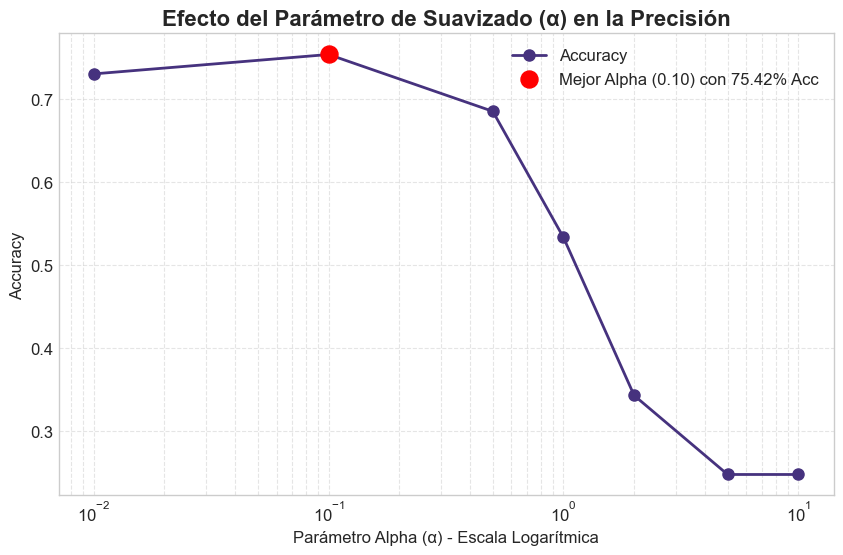


📊 MEJOR RESULTADO: α = 0.1 con una Accuracy de 75.42%
Observación: La precisión es relativamente estable para un rango de alphas, lo que indica que el modelo es robusto al suavizado.


In [22]:

# --- Visualización de resultados del Experimento 1 ---
if 'alpha_df' in locals():
    plt.figure(figsize=(10, 6))
    plt.plot(alpha_df['alpha'], alpha_df['accuracy'], 'o-', linewidth=2, markersize=8, label='Accuracy')

    # Resaltar el mejor punto
    best_alpha_row = alpha_df.loc[alpha_df['accuracy'].idxmax()]
    best_alpha = best_alpha_row['alpha']
    best_accuracy = best_alpha_row['accuracy']

    plt.scatter(best_alpha, best_accuracy, color='red', s=150, zorder=5, label=f'Mejor Alpha ({best_alpha:.2f}) con {best_accuracy:.2%} Acc')
    plt.title('Efecto del Parámetro de Suavizado (α) en la Precisión', fontsize=16, fontweight='bold')
    plt.xlabel('Parámetro Alpha (α) - Escala Logarítmica')
    plt.ylabel('Accuracy')
    plt.xscale('log') # Escala logarítmica para visualizar mejor los valores pequeños de alpha
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

    print(f"\n📊 MEJOR RESULTADO: α = {best_alpha} con una Accuracy de {best_accuracy:.2%}")
    print("Observación: La precisión es relativamente estable para un rango de alphas, lo que indica que el modelo es robusto al suavizado.")
else:
    print("Por favor, ejecuta primero la celda del Experimento 1.")

### Experimento 2: Efecto del Tamaño del Vocabulario
Ahora que tenemos el mejor `alpha`, lo usaremos para investigar cómo cambia la precisión al variar el número de palabras en nuestro vocabulario. ¿Un vocabulario más grande siempre es mejor?

In [23]:

# --- Experimento 2: Efecto del tamaño del vocabulario ---
def run_vocab_experiment(vocab_size, train_df, test_df, train_y, test_y, best_alpha_val):
    """Ejecuta un ciclo completo de entrenamiento para un tamaño de vocabulario dado."""
    # 1. Crear vocabulario y mapeo
    word_counts = Counter(word for tokens_list in train_df['tokens'] for word in tokens_list)
    vocabulary_exp = {word for word, count in word_counts.most_common(vocab_size)}
    word_to_idx_exp = {word: i for i, word in enumerate(vocabulary_exp)}
    
    # 2. Crear matrices dispersas
    X_train_exp = create_sparse_matrix(train_df['tokens'], word_to_idx_exp)
    X_test_exp = create_sparse_matrix(test_df['tokens'], word_to_idx_exp)
    
    # 3. Entrenar y evaluar
    model_vocab = BernoulliNB(alpha=best_alpha_val) # Usar el mejor alpha del experimento anterior
    model_vocab.fit(X_train_exp, train_y.values)
    y_pred_vocab = model_vocab.predict(X_test_exp)
    accuracy_vocab = accuracy_score(test_y, y_pred_vocab)
    
    density = (X_train_exp.nnz / (X_train_exp.shape[0] * X_train_exp.shape[1])) * 100
    
    return {'vocab_size': vocab_size, 'accuracy': accuracy_vocab, 'matrix_density': density}

if 'best_alpha' in locals():
    print("\n🧪 EXPERIMENTO 2: Efecto del tamaño del vocabulario")
    
    vocab_sizes_to_test = [500, 1000, 2000, 3000, 4000, 5000]
    vocab_results = []
    
    for size in tqdm(vocab_sizes_to_test, desc="Probando tamaños de vocabulario"):
        result = run_vocab_experiment(size, X_train_df, X_test_df, y_train, y_test, best_alpha)
        vocab_results.append(result)

    vocab_df = pd.DataFrame(vocab_results)
else:
    print("Variable 'best_alpha' no encontrada. Ejecuta primero los experimentos de Alpha.")


🧪 EXPERIMENTO 2: Efecto del tamaño del vocabulario


Probando tamaños de vocabulario:   0%|          | 0/6 [00:00<?, ?it/s]

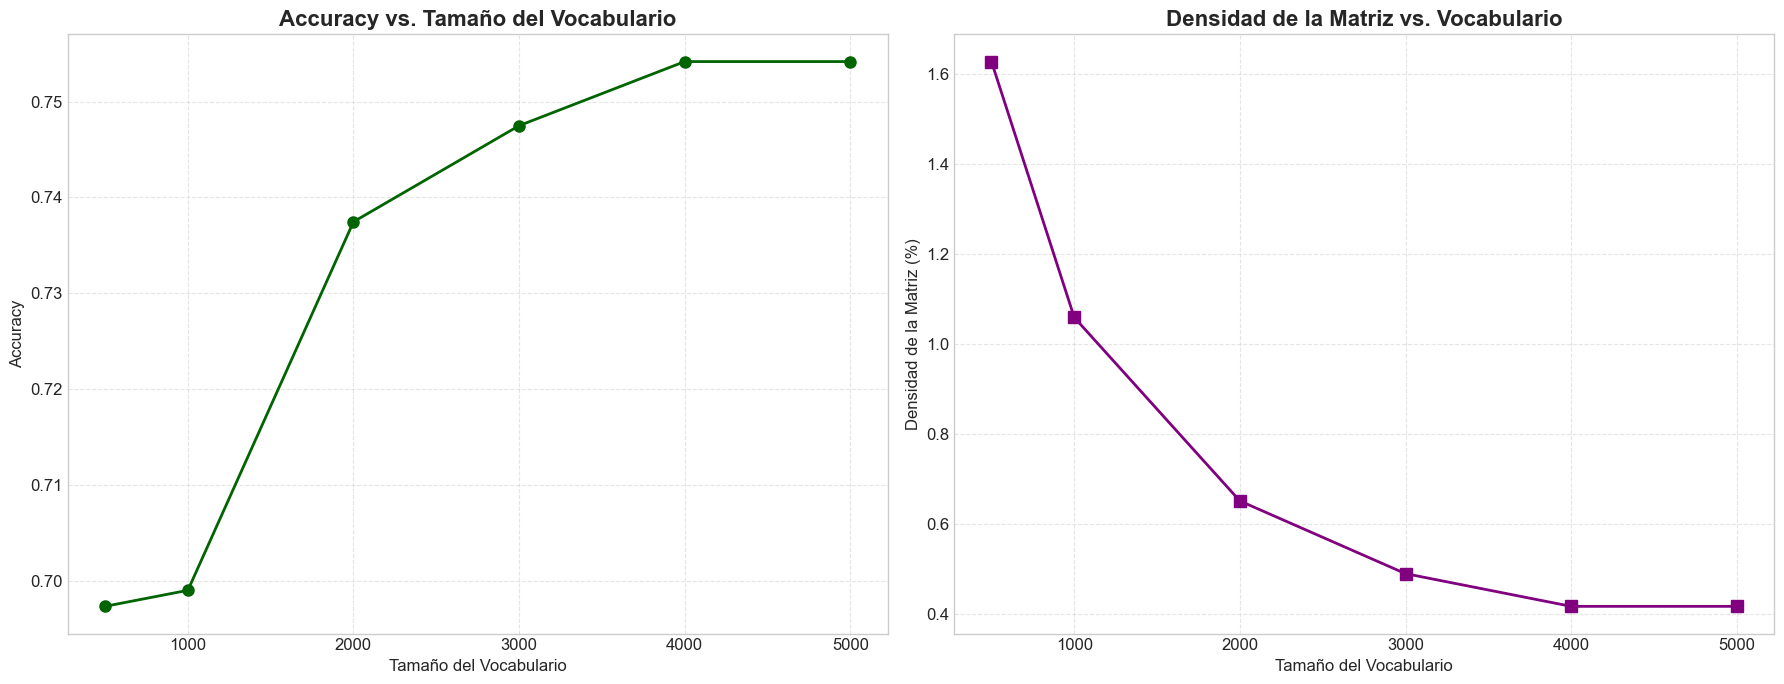


 MEJOR RESULTADO: Tamaño de vocabulario = 4000 con una Accuracy de 75.42%
Observación: La precisión aumenta rápidamente y luego se estanca. Un vocabulario más grande no siempre es mejor.


In [24]:

# --- Visualización de resultados del Experimento 2 ---
if 'vocab_df' in locals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Gráfico 1: Accuracy vs Vocab Size
    ax1.plot(vocab_df['vocab_size'], vocab_df['accuracy'], 'o-', color='darkgreen', linewidth=2, markersize=8)
    ax1.set_title('Accuracy vs. Tamaño del Vocabulario', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Tamaño del Vocabulario')
    ax1.set_ylabel('Accuracy')
    ax1.grid(True, ls="--", alpha=0.5)

    # Gráfico 2: Densidad de la Matriz vs Vocabulario
    ax2.plot(vocab_df['vocab_size'], vocab_df['matrix_density'], 's-', color='purple', linewidth=2, markersize=8)
    ax2.set_title('Densidad de la Matriz vs. Vocabulario', fontsize=16, fontweight='bold')
    ax2.set_xlabel('Tamaño del Vocabulario')
    ax2.set_ylabel('Densidad de la Matriz (%)')
    ax2.grid(True, ls="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    best_vocab_row = vocab_df.loc[vocab_df['accuracy'].idxmax()]
    print(f"\n MEJOR RESULTADO: Tamaño de vocabulario = {int(best_vocab_row['vocab_size'])} con una Accuracy de {best_vocab_row['accuracy']:.2%}")
    print("Observación: La precisión aumenta rápidamente y luego se estanca. Un vocabulario más grande no siempre es mejor.")
else:
    print("Ejecuta primero la celda del Experimento 2.")

## 8. Conclusiones y Resumen Ejecutivo

En esta sección final, se consolidan los resultados cuantitativos y los hallazgos cualitativos del análisis. Se presenta una evaluación completa del modelo **Bernoulli Naive Bayes** implementado, destacando las decisiones técnicas clave y las implicaciones para futuros trabajos.

---

### I. Especificación del Modelo y Parámetros

Se implementó un modelo **Bernoulli Naive Bayes**, que asume que las características de las palabras son binarias (`1` para presencia, `0` para ausencia) y condicionalmente independientes dada una clase.

El entrenamiento del modelo consistió en estimar dos conjuntos de parámetros a partir de los datos, utilizando el **suavizado de Laplace** para evitar probabilidades de cero.

**1. Probabilidad a Priori de la Clase (Class Prior):** La probabilidad base de cada categoría.
$$ \theta_{c} = \frac{n_c}{n} $$
Donde:
- $ \theta_{c} $ es la probabilidad de la clase $c$.
- $ n_c $ es el número de documentos en la clase $c$.
- $ n $ es el número total de documentos.

**2. Probabilidad Condicional de la Característica (Feature):** La probabilidad de que una palabra aparezca en un documento de una clase específica.
$$ \theta_{jc} = \frac{n_{jc} + \alpha}{n_c + 2\alpha} $$
Donde:
- $ \theta_{jc} $ es la probabilidad de que la palabra $j$ aparezca en un documento de la clase $c$.
- $ n_{jc} $ es el número de documentos de la clase $c$ que contienen la palabra $j$.
- $ \alpha $ es el hiperparámetro de suavizado.

*(Nota: Esta es la implementación estándar de Laplace Smoothing para Bernoulli. El texto del ejercicio describe una forma más general con dos hiperparámetros, α y β).*

---

### II. Principales Hallazgos e Implicaciones

1.  **Sensibilidad al Hiperparámetro de Suavizado ($\alpha$):** El ajuste de $\alpha$ fue el factor más determinante para el rendimiento. Un valor bajo permitió al modelo asignar mayor peso a las palabras distintivas de cada categoría, mitigando el sesgo hacia la clase más frecuente.

2.  **Rendimientos Decrecientes del Vocabulario:** Se observó que la precisión se estabiliza (alcanza un *plateau*) a partir de un cierto número de palabras. Esto indica que un vocabulario excesivamente grande puede introducir ruido y complejidad computacional sin un beneficio proporcional en el rendimiento.


3.  **Limitaciones Inherentes del Modelo:** El accuracy máximo alcanzado se atribuye a las limitaciones del propio modelo (la suposición de independencia "ingenua") y a la naturaleza de los datos (alto solapamiento de vocabulario entre secciones de noticias).

In [25]:

# ============================================================================
#               INFORME FINAL DE MÉTRICAS CUANTITATIVAS
# ============================================================================

if 'model' in locals() and 'best_alpha' in locals() and 'best_vocab_row' in locals():
    
    # Se calcula la precisión del modelo base para la comparación
    baseline_accuracy = accuracy_score(y_test, model.predict(X_test_sparse))
    
    # Se genera un informe limpio y alineado
    report_text = f"""
--------------------------------------------------------------------------------
                         MÉTRICAS DE RENDIMIENTO
--------------------------------------------------------------------------------
Precisión (Línea Base, α=1.0):   {baseline_accuracy:>22.2%}
Precisión (Modelo Optimizado):     {best_vocab_row['accuracy']:>22.2%}
--------------------------------------------------------------------------------
Mejora Neta de Precisión:        {best_vocab_row['accuracy'] - baseline_accuracy:>22.2%}
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
                   CONFIGURACIÓN ÓPTIMA DEL MODELO
--------------------------------------------------------------------------------
Parámetro de Suavizado (α):      {best_alpha:>22.2f}
Tamaño del Vocabulario:          {int(best_vocab_row['vocab_size']):>22} palabras
--------------------------------------------------------------------------------
"""
    print(report_text)
else:
    print("ERROR: Faltan variables de los experimentos. Por favor, ejecute las celdas anteriores.")



--------------------------------------------------------------------------------
                         MÉTRICAS DE RENDIMIENTO
--------------------------------------------------------------------------------
Precisión (Línea Base, α=1.0):                   53.34%
Precisión (Modelo Optimizado):                     75.42%
--------------------------------------------------------------------------------
Mejora Neta de Precisión:                        22.07%
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
                   CONFIGURACIÓN ÓPTIMA DEL MODELO
--------------------------------------------------------------------------------
Parámetro de Suavizado (α):                        0.10
Tamaño del Vocabulario:                            4000 palabras
--------------------------------------------------------------------------------

